# Применение методов bootstrap в регрессионном анализе

Данную тетрадь я решила сделать в качестве домашнего задания по статистике.  
  
**Цель работы** - показать, как в анализе данных можно использовать разные виды бутстрапа, которые я изучила: Непараметрический, полупараметрический, параметрический, и Пуассона.  

Для этой работы я буду использовать датасет **"Wine Quality"** с сайта UCI Machine Learning Repository - популярный набор данных для задач классификации или регрессии.

>"Датасет содержит физико-химические измерения и оценку качества вин из региона Vinho Verde (Португалия). Данные доступны отдельно для красного и белого вина, но структура признаков одинакова в обоих файлах."

Стоит упомянуть, что оценка качества является эмпирической, и основана на субъективном мнении специалистов. Одна из закономерных задач этого датасета - исследование зависимости оценки качества от химических характеристик вина 

Ознакомившись с набором данных, можно определить следующую структуру работы:

1. Подготовка данных ✔️  
    1.1 Проверка пропусков и дубликатов ✔️  
    1.2 Анализ выбросов ✔️  
    1.3 Масштабирование (робастное или стандартизация) ✔️   
    1.4 Проверка мультиколлинеарности (коэффициенты корреляции, VIF) ✔️
2. Построение регрессионной модели с помощью встроенной функции  
    2.1 Для общей таблицы со всеми винами ✔️  
    2.2 Дла красного и белого вина по отдельности ✔️  
    2.3 визуализация моделей (для красоты) ✔️   

3. Оценка неопределённости коэффициентов разными способами:  
    3.1 Непараметрический бутстрап (ресэмплинг наблюдений)  
    3.2 Пуассоновский бутстрап (взвешивание наблюдений)  
    3.3 Параметрический бутстрап (нормальные ошибки)  
    3.4 Полупараметрический бутстрап (ресэмплинг остатков)   
4. Сравнение методов:  
    4.1 Ширина доверительных интервалов  
    4.2 Форма распределений коэффициентов  
    4.3 Устойчивость оценок  
5. Выводы: какой из видов бутстрап более уместен для этого набора данных и построения линейной регрессии 


*\* В данной работе я не буду делить выборку на train и test, а также прибегать к кросс-валидации, так как мне важнее углубиться в бутстрап и статистику, а не в точность прогнозов и ML. Если я разобью выборки, количество данных уменьшится и коэффициенты станут менее стабильными, что повлияет на оценку разных бутстрапов*  

*\* UPD 3.03 я решила всё-таки разделить выборку на train и test, чтобы можно было вычислить R^2 и RMSE и как-то оценивать модель, чтобы как раз оценить разные виды бутстрапа. В таком случае очень заманчиво использовать кросс-валидацию для train на этапе отбора признаков, а test только один раз в конце*

Поскольку распределения и вариативность показателей химического состава существенно различаются для белых и красных вин, построение единой модели без учёта структурной неоднородности выборки может привести к смещённым оценкам коэффициентов. В связи с этим регрессионный анализ проводится отдельно для белых и красных вин.

Дополнительно будеь оценена объединённая модель, в которую содержит фиктивную переменная, отражающую тип вина.

#### Импорт библиотек

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display, Markdown

---
### Обзор и подготовка данных
---

In [ ]:
# загрузка датасета
df_red = pd.read_csv('winequality-red.csv', sep=';')
df_white = pd.read_csv('winequality-white.csv', sep=';')

# создадим общую таблицу с пометкой is_red = 1 для красных вин и 0 для белых
df_red['is_red'] = 1
df_white['is_red'] = 0

# соединим таблицы
df_full = pd.concat([df_red, df_white], ignore_index=True)
df_full.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,is_red
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1


#### Информация о таблице

**Описание данных**  
Признаки химического состава вина (все числовые и непрерывные):  

1. <span style='font-family: monospace; background-color: #7A716F'>fixed acidity</span> — фиксированная (нелетучая) кислотность, измеряется в граммах на децилитр (g/dm³)  
2. <span style='font-family: monospace; background-color: #7A716F'>volatile acidity</span> — летучая кислотность (g/dm³)  
3. <span style='font-family: monospace; background-color: #7A716F'>citric acid</span> — лимонная кислота (g/dm³)  
4. <span style='font-family: monospace; background-color: #7A716F'>residual sugar</span> — остаточный сахар (g/dm³)  
5. <span style='font-family: monospace; background-color: #7A716F'>chlorides</span> — хлориды, концентрация солей хлора (g/dm³)   
6. <span style='font-family: monospace; background-color: #7A716F'>free sulfur dioxide</span> — свободный диоксид серы, измеряется в миллиграммах на литр (mg/L)  
7. <span style='font-family: monospace; background-color: #7A716F'>total sulfur dioxide</span> — общее содержание диоксида серы (mg/L)  
8. <span style='font-family: monospace; background-color: #7A716F'>density</span> — плотность, безразмерная величина (масса/объём), измеряется в граммах на кубический сантиметр (g/cm³)  
9. <span style='font-family: monospace; background-color: #7A716F'>pH</span> — уровень pH (кислотно-щелочной баланс), по шкале от 0 до 14
10. <span style='font-family: monospace; background-color: #7A716F'>sulphates</span> — сульфаты, измеряются в граммах на децилитр (g/dm³)  
11. <span style='font-family: monospace; background-color: #7A716F'>alcohol</span> — содержание алкоголя, измеряется в проценте по объёму (% vol)  

Целевая переменная 
 
12. <span style='font-family: monospace; background-color: #7A716F'>quality</span> — оценка качества вина, целое число (0–10).
Это субъективная оценка экспертов дегустации: чем выше число, тем лучше воспринимаемое качество. 

Фиктивная переменная

13.  <span style='font-family: monospace; background-color: #7A716F'>is_red</span> - указывает на цвет вина и принадлежность к таблице df_red или df_white, 1 для красных вин и 0 для белых.

In [ ]:
# выведем общую информацию о таблице
df_full.info()
print()
print(f'Записей о красных винах {len(df_red)}')
print(f'Записей о белых винах {len(df_white)}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  is_red                6497 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 660.0 KB

Записей о красных винах 1599
Записей о белых винах 4898


В таблице объёмом 6497 строк, 13 столбцов содержатся следующие типы данных: float64, int64.  
В дальнейшем данные с типом float64 будут преобразованы во float32 для экономии памяти и оптимизации обучения моделей

Пропусков в данных нет. Проверим, есть ли дубликаты

In [ ]:
print(f'В таблице есть повторяющиеся строки: {df_full.duplicated().any()}')
# количество дубликатов, не считая первого вхождения строки
print(f'Количество дубликатов: {df_full.duplicated(keep="first").sum()}')

В таблице есть повторяющиеся строки: True
Количество дубликатов: 1177


В датасете целых 1177 дубликата. Изучим их

In [ ]:
# проверим 10 самых больших чисел дубликатов в таблице (количество дублей запишем в последний столбец вывода)
duplicate_counts = (
    df_full[df_full.duplicated(keep=False)]
    .groupby(df_full.columns.tolist())
    .size()
    .reset_index(name='duplicate_count')
    .sort_values(by='duplicate_count', ascending=False)
)

print(f"Всего уникальных комбинаций с дублями: {len(duplicate_counts)}")
print(f"Топ-20 самых частых:")
duplicate_counts.head(15)

Всего уникальных комбинаций с дублями: 992
Топ-20 самых частых:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,is_red,duplicate_count
460,7.0,0.15,0.28,14.7,0.051,29.0,149.0,0.99792,2.96,0.39,9.0,7,0,8
622,7.3,0.19,0.27,13.9,0.057,45.0,155.0,0.99807,2.94,0.41,8.8,8,0,8
661,7.4,0.16,0.30,13.7,0.056,33.0,168.0,0.99825,2.90,0.44,8.7,7,0,7
360,6.8,0.18,0.30,12.8,0.062,19.0,171.0,0.99808,3.00,0.52,9.0,7,0,7
728,7.6,0.20,0.30,14.2,0.056,53.0,212.5,0.99900,3.14,0.46,8.9,8,0,6
660,7.4,0.16,0.27,15.5,0.050,25.0,135.0,0.99840,2.90,0.43,8.7,7,0,6
664,7.4,0.19,0.30,12.8,0.053,48.5,229.0,0.99860,3.14,0.49,9.1,7,0,6
665,7.4,0.19,0.31,14.5,0.045,39.0,193.0,0.99860,3.10,0.50,9.2,6,0,6
684,7.4,0.33,0.26,15.6,0.049,67.0,210.0,0.99907,3.06,0.68,9.5,5,0,5
118,6.2,0.23,0.36,17.2,0.039,37.0,130.0,0.99946,3.23,0.43,8.8,6,0,5


UPD 3.03 Я решила всё-таки удалить дубликаты. Да, это могут быть реально повторяющиеся составы вин, но модели не нужно знать какой набор признаков встречается чаще, а какой - реже, ей нужно значить как они влияют на оценку качества, и точки дубликаты будут иметь больший вес по сравнению с другими, а также если одинаковые строки попадут в train и в test, показатели модели будут искажены, так как она просто запомнит строку и повторит результат

Как видно по последнему столбцу с подсчётом дубликатов, они не экстремальные, максимум 8. Примечательно, что множественные совпадения (5-8 записей) встречаются только в таблице с белыми винами. Вероятно, это связанно с большим объёмом информации о белых винах, нежели красных (~4900 белых и ~1600 красных) и с округлением лабораторных показателей до определённой точности. Поскольку данные не содержат идентификаторов объектов, совпадающие строки рассматриваются как независимые наблюдения и не удаляются, чтобы сохранить реальное распределение признаков.

#### Выводы
Представленные данные содержат количественные характеристики химического состава вин и качественный признак - эмпирическую оценку экспертов.  

Предварительно можно утверждать, что данных достаточно для обучения моделей

In [ ]:
# Ячейку выше можно удалить
# Удаляем дубли на месте
#df_full.drop_duplicates(keep='first', inplace=True)

#### Train test split

Всего в таблице 6,5 тысяч строк. Для данного размера подойдёт такая пропорция: 80% для обучения и 20% для тестирования

In [ ]:
from sklearn.model_selection import train_test_split

# -- красное --
red_train, red_test = train_test_split(df_red, test_size=0.2, random_state=42)

# -- белое --
white_train, white_test = train_test_split(df_white, test_size=0.2, random_state=42)

# -- полная выборка --
full_train = pd.concat([red_train, white_train])
full_test  = pd.concat([red_test, white_test])

Далее любые процедуры будем проводить только на тренировочных выборках

#### Выбросы и масштабирование

Посмотрим, есть ли выбросы в данных

In [ ]:
index = full_train.columns.drop(['is_red', 'quality'])
df_outliers = pd.DataFrame()
df_outliers['характеристика'] = index
for i in range(3):
    df = [full_train, red_train, white_train][i]
    name = ['общая таблица', 'красное', 'белое'][i]
    res_col = []
    for column in df.columns:
        if column not in ['is_red', 'quality']:
            res_col.append(detect_outliers_iqr(df, column))
    df_outliers[name] = res_col

# сортируем по максимальному среднему числу выбросов по трём таблицам
df_outliers = df_outliers.loc[df_outliers[['общая таблица', 'красное', 'белое']].mean(axis=1).sort_values(ascending=False).index]

display(Markdown('Количество выбросов в процентах'))
display(df_outliers)

Количество выбросов в процентах

,характеристика,общая таблица,красное,белое
4,chlorides,4.4,6.9,4.1
2,citric acid,7.8,0.1,6.3
3,residual sugar,1.8,10.1,0.2
0,fixed acidity,5.5,3.0,2.6
9,sulphates,2.9,3.9,2.6
1,volatile acidity,4.9,1.4,3.0
8,pH,1.2,2.1,1.5
6,total sulfur dioxide,0.1,3.4,0.3
5,free sulfur dioxide,1.0,1.6,1.1
7,density,0.1,2.7,0.1


В получившейся таблице заметны выбросы, которые нельзя оставлять без внимания: <span style='font-family: monospace; background-color: #7A716F'>chlorides</span>, <span style='font-family: monospace; background-color: #7A716F'>citric acid</span>, <span style='font-family: monospace; background-color: #7A716F'>residual sugar</span>, <span style='font-family: monospace; background-color: #7A716F'>fixed acidity</span> и <span style='font-family: monospace; background-color: #7A716F'>volatile acidity</span> имеют серьёзные проценты аномальных значений. 

Линейная регрессия чувствительна к масштабу признаков и наличию выбросов, поэтому перед оценкой модели применим робастное масштабирование, основанное на использовании медианы и межквартильного размаха. Данный подход обеспечивает устойчивость результатов к экстремальным значениям фичей.

In [ ]:
# импортируем робастный скейлер
from sklearn.preprocessing import RobustScaler

# 3 разных скейлера для разных выборок
scaler_red = RobustScaler()
scaler_white = RobustScaler()
scaler_full = RobustScaler()

# --- Красные ---
# разделение на зависимую и независимые переменные
X_red_train = red_train.drop(['quality', 'is_red'], axis=1) # Не масштабируем зависимую переменную и фиктивную - там масштабировать нечего
y_red_train = red_train['quality']

# Непосредственно масштабирование
X_red_train_scaled = scaler_red.fit_transform(X_red_train)

# Преобразование обратно в DataFrame для удобства
X_red_train_scaled = pd.DataFrame(X_red_train_scaled, columns=X_red_train.columns, index=X_red_train.index)

# --- Белые --- (всё то же самое)
X_white_train = white_train.drop(['quality', 'is_red'], axis=1) 
y_white_train = white_train['quality']

X_white_train_scaled = scaler_white.fit_transform(X_white_train)
X_white_train_scaled = pd.DataFrame(X_white_train_scaled, columns=X_white_train.columns, index=X_white_train.index)


# --- Полная выборка ---
X_full_train = full_train.drop('quality', axis=1)
y_full_train = full_train['quality']

X_full_train_scaled = scaler_full.fit_transform(X_full_train)
X_full_train_scaled = pd.DataFrame(X_full_train_scaled, columns=X_full_train.columns, index=X_full_train.index)

In [ ]:
# Проверим медиану и межквартильный размах. После масштабирования медиана должна быть около 0, IQR около 1
for df in [X_red_train_scaled, X_white_train_scaled, X_full_train_scaled]:
    scaler_check = df.describe().T[['25%', '50%', '75%']] # берём из перевёрнутого df.describe квартили
    scaler_check['IQR'] = scaler_check['75%'] - scaler_check['25%'] # считаем межквартильный размах
    print(scaler_check)
    print()

                           25%  50%       75%  IQR
fixed acidity        -0.380952  0.0  0.619048  1.0
volatile acidity     -0.500000  0.0  0.500000  1.0
citric acid          -0.484848  0.0  0.515152  1.0
residual sugar       -0.428571  0.0  0.571429  1.0
chlorides            -0.450000  0.0  0.550000  1.0
free sulfur dioxide  -0.500000  0.0  0.500000  1.0
total sulfur dioxide -0.390244  0.0  0.609756  1.0
density              -0.522831  0.0  0.477169  1.0
pH                   -0.526316  0.0  0.473684  1.0
sulphates            -0.388889  0.0  0.611111  1.0
alcohol              -0.437500  0.0  0.562500  1.0

                           25%  50%       75%  IQR
fixed acidity        -0.500000  0.0  0.500000  1.0
volatile acidity     -0.416667  0.0  0.583333  1.0
citric acid          -0.454545  0.0  0.545455  1.0
residual sugar       -0.421687  0.0  0.578313  1.0
chlorides            -0.500000  0.0  0.500000  1.0
free sulfur dioxide  -0.434783  0.0  0.565217  1.0
total sulfur dioxide -0.440678

Теперь все медианы и межквартильные размахи числовых характеристик равны соответственно 0 и 1. Значит масштабирование сработало правильно. 

#### Мультиколлинеарность и регуляризация

Проверим признаки на мультиколлинеарность.
Для этого построим матрицу парных коэффициентов корреляции Пирсона между всеми независимыми переменными

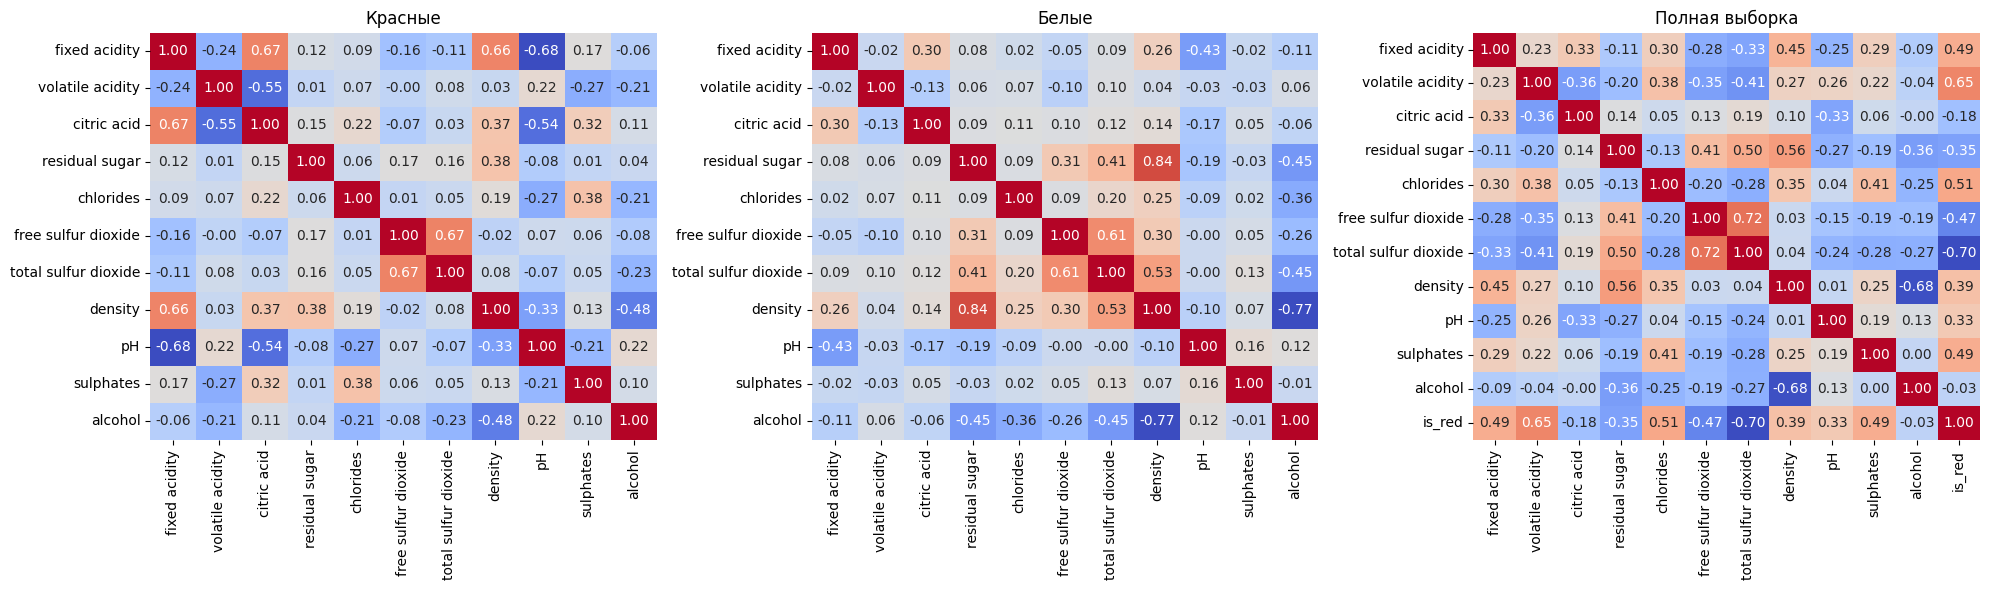

In [ ]:
datasets = [X_red_train_scaled, X_white_train_scaled, X_full_train_scaled]
names = ['Красные', 'Белые', 'Полная выборка']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
# Матрицы корреляций
for i, df in enumerate(datasets):
    corr_matrix = df.corr(method='pearson')

    # Визуализация с помощью тепловой карты
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[i], cbar=False)
    axes[i].set_title(names[i])
        

plt.tight_layout() 
plt.show()

Ниже представлены "проблемные" пары, у которых коэффициент корреляции по модулю >= 0,6


Сильные корреляции у красных:

- fixed acidity — pH (~ -0.68)

- fixed acidity - citric acid (~ 0.67)

- free sulfur dioxide — total sulfur dioxide (~ 0.67)

- fixed acidity	- density (~ 0.66)


У белых:

- residual sugar — density (~0.84) - очень сильная корреляция

- density — alcohol (~ -0.77)



В полной выборке:

- free sulfur dioxide — total sulfur dioxide (~0.72)

- density — alcohol (~ -0.68)

*\*Любопытно посмотреть на корреляции с переменной is_red. Можно сделать вывод, что у красных вин летучая кислотность (volatile acidity) больше, чем у белых, а общее содержание диоксида серы (total sulfur dioxide) - меньше.*

**Указанные выше пары скорее всего вызовут мультиколлинеарность в линейной регрессии**

**Рассчитаем коэффициент инфляции дисперсии или VIF**  
*Чтобы лучше оценить угрозу мультиколлинеарности*
В матрицу признаков добавим свободный член (константу), чтобы обеспечить корректную оценку коэффициента детерминации R^2
во вспомогательных регрессиях, используемых при расчёте показателя VIF. 

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Представим максимально коррелированные независимые переменные по парам
for idx, df in enumerate(datasets):

    # рассчёт коэффициента корреляции Пирсона
    corr_matrix = df.corr(method='pearson') # матрица корреляций
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)) # Оставляем только верхний треугольник без диагонали
    corr_pairs = (upper.stack().reset_index()) # Преобразуем в "длинный" формат
    corr_pairs.columns = ['признак 1', 'признак 2', 'корреляция'] # Названия полей для красоты
    corr_pairs['модуль корреляции'] = corr_pairs['корреляция'].abs() # Добавляем модуль корреляции для сортировки

    top_corr = corr_pairs.sort_values(by='модуль корреляции', ascending=False).head(5).copy() # топ-5 по абсолютному значению корреляции
    top_features = pd.unique(top_corr[['признак 1', 'признак 2']].values.ravel()) # Определяем уникальные признаки из топ-5

    # Создаём датафрейм с уникальными признаками + константой
    df_top = df[top_features.tolist()].copy()
    df_top['const'] = 1

    # Расчёт VIF
    vif = []
    for i in range(df_top.shape[1]):
        try:
            vif.append(variance_inflation_factor(df_top.values, i))
        except:
            vif.append(np.nan)

    top_corr_vif = top_corr.copy()

    # Берём VIF для каждого уникального признака
    feature_vif_map = dict(zip(df_top.columns, vif))
    top_corr_vif['VIF признак 1'] = top_corr_vif['признак 1'].map(feature_vif_map)
    top_corr_vif['VIF признак 2'] = top_corr_vif['признак 2'].map(feature_vif_map)

    display(Markdown(f'### {names[idx]}'))
    # Подсветка где > 5
    display(top_corr_vif.style.map(
        lambda v: 'background-color: #E6B0A8'
        if isinstance(v, (int, float)) and v > 5
        else ''
    )
)

### Красные

,признак 1,признак 2,корреляция,модуль корреляции,VIF признак 1,VIF признак 2
7,fixed acidity,pH,-0.676197,0.676197,4.377511,2.099842
1,fixed acidity,citric acid,0.669197,0.669197,4.377511,2.723720
40,free sulfur dioxide,total sulfur dioxide,0.668166,0.668166,1.915613,2.127234
6,fixed acidity,density,0.660577,0.660577,4.377511,2.105530
10,volatile acidity,citric acid,-0.545491,0.545491,1.631432,2.723720


### Белые

,признак 1,признак 2,корреляция,модуль корреляции,VIF признак 1,VIF признак 2
30,residual sugar,density,0.843055,0.843055,5.582892,11.461195
51,density,alcohol,-0.774568,0.774568,11.461195,3.883539
40,free sulfur dioxide,total sulfur dioxide,0.614191,0.614191,1.698282,2.116821
45,total sulfur dioxide,density,0.531515,0.531515,2.116821,11.461195
48,total sulfur dioxide,alcohol,-0.454442,0.454442,2.116821,3.883539


### Полная выборка

,признак 1,признак 2,корреляция,модуль корреляции,VIF признак 1,VIF признак 2
45,free sulfur dioxide,total sulfur dioxide,0.721545,0.721545,2.232722,3.965424
55,total sulfur dioxide,is_red,-0.701174,0.701174,3.965424,6.526958
58,density,alcohol,-0.682294,0.682294,7.828452,2.739718
20,volatile acidity,is_red,0.653796,0.653796,1.809238,6.526958
33,residual sugar,density,0.561796,0.561796,4.268073,7.828452


В подвыборке красных вин значения коэффициента инфляции дисперсии (VIF) для признаков находятся на допустимом уровне. Это свидетельствует о том, что вероятность выраженной мультиколлинеарности небольшая.

В подвыборке белых вин, напротив, выявлены признаки потенциальной мультиколлинеарности: для переменной residual sugar наблюдается повышенное значение VIF (5,58), а для переменной density — очень высокое значение VIF (11,5). Кроме того, между residual sugar и density зафиксирована высокая линейная зависимость (коэффициент корреляции Пирсона r = 0,84), что указывает на значительную степень взаимосвязанности данных признаков и повышенный риск мультиколлинеарности в модели.

В полной выборке также наблюдается повышенное значение VIF для переменной density (7,8). Данный признак демонстрирует заметную корреляцию с переменными alcohol и residual sugar, что может указывать на наличие умеренной мультиколлинеарности в полной модели.

**Чтобы избежать мультиколлинеарности, но также не "выкидывать" признаки из моделей, используем L2 (Ridge) регуляризацию и комбинацию L2 и L1 регуляризаций - elastic net для белых вин и полной выборки** 

---
### Построение регрессионных моделей
---

### Веса для красных вин

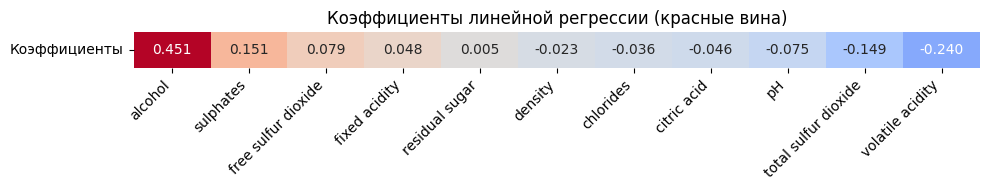

### Веса для белых вин

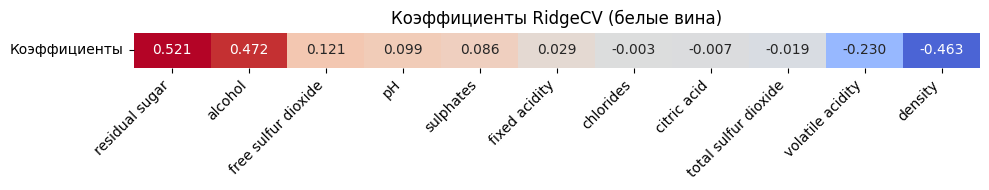

### Веса для полной выборки

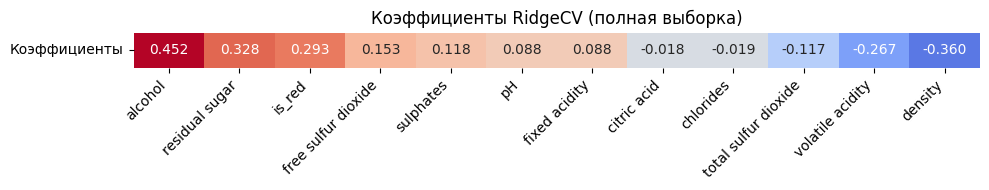

In [41]:
# обычная линейная регрессия без регуляризации для красного вина
from sklearn.linear_model import LinearRegression

X = X_red_train_scaled # берём все фичи без фиктивной переменной
y = y_red_train
# сохраняем список признаков, на которых обучалась модель (здесь это не совсем нужно, но я буду так делать потом, когда возможно выкину некоторые признаки, это некая "хорошая привычка")
features_red = X.columns.tolist() 

model_red = LinearRegression()
model_red.fit(X, y)

# просто посмотреть на веса
display(Markdown(f'### Веса для красных вин'))
plot_coefficients_heatmap(
    model_red,
    X_red_train_scaled.columns,
    'Коэффициенты линейной регрессии (красные вина)'
)

# ridge с кросс-валидацией для белого вина и полной выборки. 
# Кросс-валидация сама подбирает нужное значение alpha. Используем её здесь, так как важна обобщающая способность модели, 
# а также данных немного, вычислительные мощности экономить не нужно
# данные предварительно масштабированы
from sklearn.linear_model import RidgeCV

# -- белые --
X = X_white_train_scaled
y = y_white_train
features_white = X.columns.tolist()

model_white = RidgeCV(alphas=[0.1, 1.0, 10.0], cv=5) # классические значения аргументов
model_white.fit(X, y)
# смотрим веса
coef_df = pd.DataFrame({'Признак': X.columns,'Коэффициент': model_white.coef_})
display(Markdown(f'### Веса для белых вин'))
plot_coefficients_heatmap(
    model_white,
    X_white_train_scaled.columns,
    'Коэффициенты RidgeCV (белые вина)'
)

# -- полная выборка --
X = X_full_train_scaled
y = y_full_train
features_full = X.columns.tolist()

model_full = RidgeCV(alphas=[0.1, 1.0, 10.0], cv=5)
model_full.fit(X, y)
coef_df = pd.DataFrame({'Признак': X.columns,'Коэффициент': model_full.coef_})
display(Markdown(f'### Веса для полной выборки'))
plot_coefficients_heatmap(
    model_full,
    X_full_train_scaled.columns,
    'Коэффициенты RidgeCV (полная выборка)'
)

#### UPD 3.03 Теперь можно оценить эту модель! (вау)

Для этого вычислим коэффициент детерминации (R²) и среднеквадратичную ошибку (RMSE)

In [42]:
from sklearn.metrics import r2_score, mean_squared_error

# Словарь с моделями, признаками, тестовыми выборками и масштабированием. Чтобы находить характеристики моделей одним циклом
tests = {
    'Красные': {
        'model': model_red,
        'X': red_test[features_red],
        'y': red_test['quality'],
        'scaler': scaler_red  # тот же скейлер, что на тренировочном наборе
    },
    'Белые': {
        'model': model_white,
        'X': white_test[features_white],
        'y': white_test['quality'],
        'scaler': scaler_white
    },
    'Полная выборка': {
        'model': model_full,
        'X': full_test[features_full],
        'y': full_test['quality'],
        'scaler': scaler_full
    }
}

# Цикл по всем наборам
for name, data in tests.items():
    # масштабируем тестовую выборку
    X_test_scaled = data['scaler'].transform(data['X'])
    
    # предсказания модели
    y_pred = data['model'].predict(X_test_scaled)
    
    # r2
    r2 = r2_score(data['y'], y_pred)
    # RMSE - корень из средней квадратичной ошибки
    rmse = np.sqrt(mean_squared_error(data['y'], y_pred))
    
    print(f'--- {name} ---')
    print(f'R²: {r2:.3f}')
    print(f'RMSE: {rmse:.3f}\n')

--- Красные ---
R²: 0.403
RMSE: 0.625

--- Белые ---
R²: 0.263
RMSE: 0.755

--- Полная выборка ---
R²: 0.297
RMSE: 0.728



/Users/alferova_tv/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Users/alferova_tv/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RidgeCV was fitted with feature names
  warnings.warn(
/Users/alferova_tv/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RidgeCV was fitted with feature names
  warnings.warn(


**Анализ характеристик моделей**

🍷 Красные

R² = 0.403
Модель объясняет ~40% вариации целевой переменной.
Для прикладных задач это умеренно хорошее качество, но можно и лучше

RMSE = 0.625
Средняя ошибка прогноза — 0.625 ≈ 0.63 балла по 10-балльной шкале.

Лучшая из трёх линейных моделей.

🍷 Белые

R² = 0.265
Объясняет 26.5% вариации — заметно слабее предыдущей.

RMSE = 0.754
Ошибка ≈ 0.75 балла.

Данные по белым хуже объясняются линейной моделью.

🍷 Полная выборка

R² = 0.297
Объясняет 30% вариации.  

RMSE = 0.728
Любопытно, что качество хуже, чем у красных отдельно.

Это может говорить о том, что механизмы формирования целевой переменной для красных и белых различаются6 и когда они объединяются, модель "усредняет" зависимости, коэффициенты становятся компромиссными.

### 3. Оценка неопределённости коэффициентов с помощью bootstrap 

Посмотрим, какие коэффициенты вносят больший вклад в оценку качества вина, а какие - менее важны

**Для этого используем непараметрический бутстрап**   

Суть данного метода - создание новых наборов наблюдений путём случайного выбора с возвращением из исходных данных. При этом не делается никаких предположений о распределении данных (в отличии от параметрического bootstrap'a)

Ниже будет сделано 3000 бутстрап-выборок. На каждой репликации обучается новая модель, её коэффициенты фиксируются. После завершения всех итераций анализируем распределения коэффициентов.

In [43]:
coef_boot_red = nonparametric_bootstrap(LinearRegression(), X_red_train_scaled, y_red_train, n=3000, random_state=42)

boot_table(coef_boot_red)

,медиана,стандартное отклонение,ДИ 2.5%,ДИ 97.5%
chlorides,-0.035573,0.010263,-0.056716,-0.015895
residual sugar,0.004498,0.015141,-0.025185,0.033951
sulphates,0.151759,0.025771,0.106001,0.208281
total sulfur dioxide,-0.147785,0.034711,-0.216903,-0.080451
free sulfur dioxide,0.077805,0.036127,0.005806,0.147860
volatile acidity,-0.239215,0.036770,-0.310317,-0.168578
pH,-0.074842,0.045497,-0.163781,0.012597
alcohol,0.452582,0.050518,0.354568,0.554398
citric acid,-0.050770,0.058438,-0.162846,0.067549
density,-0.023545,0.060901,-0.141539,0.098285


Как видно из результатов, для ряда признаков ноль входит в доверительный интервал коэффициентов. К таким признакам относятся residual sugar, pH, citric acid, density и fixed acidity. Эти признаки можно назвать статистически незначимыми. Попробуем обучить модель без них и посмотрим, какие показатели у неё будут. ТУТ ПОЯСНЕНИЕ ПРО ТО, ЧТО ВООБЩЕ-ТО УДАЛЯТЬ ПРИЗНАКИП НЕ ВСЕГДА ХОРОШО

### Веса для красных вин с урезанным числом признаков

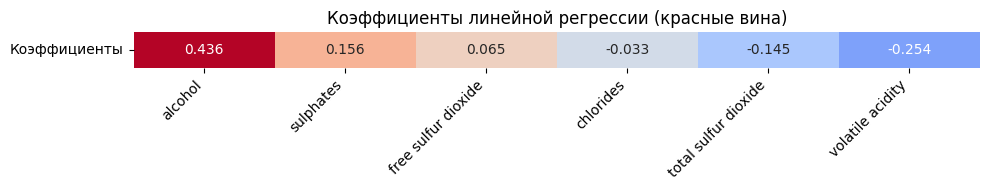

R²: 0.394
RMSE: 0.629



In [44]:
X = X_red_train_scaled.drop(['residual sugar', 'pH', 'citric acid', 'density', 'fixed acidity'], axis=1)
y = y_red_train
new_red_features = X.columns.tolist() 

# Обучаем новый scaler на урезанном наборе признаков 
X_train_reduced = red_train[new_red_features]
y_train = red_train['quality']

scaler_red_new = RobustScaler()
X_train_scaled = scaler_red_new.fit_transform(X_train_reduced)

# обучаем модель
model_red_new = LinearRegression()
model_red_new.fit(X_train_scaled, y_train)

# посмотрим веса
display(Markdown(f'### Веса для красных вин с урезанным числом признаков'))
plot_coefficients_heatmap(
    model_red_new,
    new_red_features,
    'Коэффициенты линейной регрессии (красные вина)'
)

# теперь тест
X_test_reduced = red_test[new_red_features]
X_test_scaled = scaler_red_new.transform(X_test_reduced) # масштабирование тестовой выборки

# предсказания модели
y_pred = model_red_new.predict(X_test_scaled)
y_test = red_test['quality']
    
# r2
r2 = r2_score(y_test, y_pred)
# RMSE 
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    

print(f'R²: {r2:.3f}')
print(f'RMSE: {rmse:.3f}\n')

Попробуем непараметрический бутстрап для двух других выборок

In [45]:
# -- белые --
coef_boot_white = nonparametric_bootstrap(RidgeCV(alphas=[0.1, 1.0, 10.0], cv=5), X_white_train_scaled, y_white_train, n=3000, random_state=42)
boot_table(coef_boot_white)

# -- полная выборка --
coef_boot_full = nonparametric_bootstrap(RidgeCV(alphas=[0.1, 1.0, 10.0], cv=5), X_full_train_scaled, y_full_train, n=3000, random_state=42)
boot_table(coef_boot_full)

,медиана,стандартное отклонение,ДИ 2.5%,ДИ 97.5%
chlorides,-0.001193,0.007914,-0.017071,0.014182
citric acid,-0.006803,0.010727,-0.027562,0.014687
volatile acidity,-0.230101,0.015522,-0.258745,-0.199859
sulphates,0.089408,0.017466,0.056764,0.124518
free sulfur dioxide,0.119078,0.026469,0.065339,0.167773
total sulfur dioxide,-0.013618,0.028283,-0.066912,0.042519
pH,0.108739,0.034462,0.056599,0.185399
fixed acidity,0.037657,0.040776,-0.017258,0.129690
alcohol,0.460572,0.106261,0.212821,0.570766
residual sugar,0.538893,0.138543,0.393491,0.863393


,медиана,стандартное отклонение,ДИ 2.5%,ДИ 97.5%
chlorides,-0.018718,0.009874,-0.037573,0.001506
citric acid,-0.017534,0.011932,-0.041372,0.004838
sulphates,0.119651,0.014470,0.091463,0.147538
volatile acidity,-0.267732,0.017758,-0.301243,-0.232268
pH,0.092099,0.024151,0.046489,0.143091
free sulfur dioxide,0.152047,0.025271,0.102704,0.202521
fixed acidity,0.093150,0.027930,0.042693,0.153813
total sulfur dioxide,-0.114226,0.028197,-0.167109,-0.057719
alcohol,0.445282,0.044841,0.343817,0.515511
residual sugar,0.339065,0.052453,0.256054,0.455317


В выборке с белыми винами модно заметить следующие статистически незначимые признаки: chlorides, citric acid, total sulfur dioxide, fixed acidity. Попробуем удалить их из модели    

Тут у нас признаки, коэффициенты которых проходят через 0 следующие: chlorides, citric acid, total sulfur dioxide. Попробуем их отбросить и посмотрим, что будет ПЕРЕПИСАТЬ ПО-НАУЧНОМУ

### Коэффициенты для белых вин

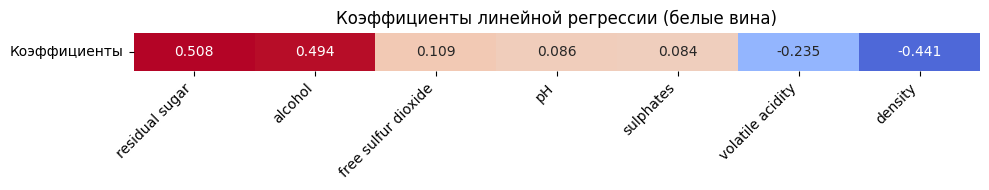

--- Белые вина с урезанным числом признаков ---
R²: 0.261
RMSE: 0.756



### Коэффициенты для общей выборки

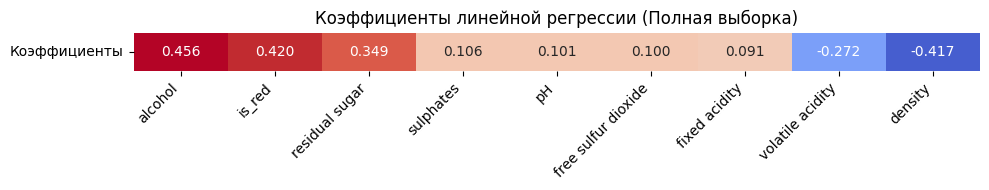

--- Общая выборка с урезанным числом признаков ---
R²: 0.295
RMSE: 0.729



In [46]:
# -- БЕЛЫЕ --
X = X_white_train_scaled.drop(['chlorides', 'citric acid', 'total sulfur dioxide', 'fixed acidity'], axis=1)
y = y_white_train
new_white_features = X.columns.tolist()

# Обучаем новый scaler на урезанном наборе признаков 
X_train_reduced = white_train[new_white_features]
y_train = white_train['quality']

scaler_white_new = RobustScaler()
X_train_scaled = scaler_white_new.fit_transform(X_train_reduced)

# обучаем модель
model_white_new = RidgeCV(alphas=[0.1, 1.0, 10.0], cv=5)
model_white_new.fit(X_train_scaled, y_train)

# посмотрим веса
display(Markdown(f'### Коэффициенты для белых вин'))
plot_coefficients_heatmap(
    model_white_new,
    new_white_features,
    'Коэффициенты линейной регрессии (белые вина)'
)

# теперь тест
X_test_reduced = white_test[new_white_features]
X_test_scaled = scaler_white_new.transform(X_test_reduced)

# предсказания модели
y_pred = model_white_new.predict(X_test_scaled)
y_test = white_test['quality']

r2 = r2_score(y_test, y_pred) # r2
rmse = np.sqrt(mean_squared_error(y_test, y_pred)) # RMSE 
    
print(f'--- Белые вина с урезанным числом признаков ---')
print(f'R²: {r2:.3f}')
print(f'RMSE: {rmse:.3f}\n')

# -- ПОЛНАЯ ВЫБОРКА --
X = X_full_train_scaled.drop(['chlorides', 'citric acid', 'total sulfur dioxide'], axis=1)
y = y_full_train
new_full_features = X.columns.tolist()

# Обучаем новый scaler на урезанном наборе признаков 
X_train_reduced = full_train[new_full_features]
y_train = full_train['quality']

scaler_full_new = RobustScaler()
X_train_scaled = scaler_full_new.fit_transform(X_train_reduced)

# обучаем модель
model_full_new = RidgeCV(alphas=[0.1, 1.0, 10.0], cv=5)
model_full_new.fit(X_train_scaled, y_train)

# посмотрим веса
display(Markdown(f'### Коэффициенты для общей выборки'))
plot_coefficients_heatmap(
    model_full_new,
    new_full_features,
    'Коэффициенты линейной регрессии (Полная выборка)'
)

# теперь тест
X_test_reduced = full_test[new_full_features]
X_test_scaled = scaler_full_new.transform(X_test_reduced)

# предсказания модели
y_pred = model_full_new.predict(X_test_scaled)
y_test = full_test['quality']
    
r2 = r2_score(y_test, y_pred) # r2
rmse = np.sqrt(mean_squared_error(y_test, y_pred)) # RMSE 
    
print(f'--- Общая выборка с урезанным числом признаков ---')
print(f'R²: {r2:.3f}')
print(f'RMSE: {rmse:.3f}\n')

Чуть хуже, но почти не изменилось КАКИЕ БЫЛИ ПРЕДЫДУЩИЕ

Попробуем на полной выборке, вдруг произойдёт чудо

Ничего не изменилось. Но вот вопрос: это те же самые 30% вариации, что и в первый раз, или другие?

Поскольку в рамках данной работы оценивается прогностическая способность моделей, имеет смысл рассмотреть более современные и гибкие методы по сравнению с линейными моделями, в частности алгоритм случайного леса. Посмотрим, насколько лучше станет предсказательная способность по-сравнению с результатами ранее рассмотренных линейных моделей.

In [47]:
from sklearn.ensemble import RandomForestRegressor

rf_red, rf_white, rf_full = [None for _ in range(3)] # переменные для моделей
# Словарь словарей с моделями, признаками, тестовыми и тренировочными выборками. Чтобы обучать и находить характеристики моделей одним циклом
rf_dct = {
    'Красные вина': {
        'model': rf_red,
        'X_train': red_train.drop('quality', axis=1), # случайный лес не чувствителен к масштабу -> используем немасштабированные данные
        'y_train': red_train['quality'],
        'X_test': red_test.drop('quality', axis=1),
        'y_test': red_test['quality']
    }, 
    'Белые вина': {
        'model': rf_white,
        'X_train': white_train.drop('quality', axis=1),
        'y_train': white_train['quality'],
        'X_test': white_test.drop('quality', axis=1),
        'y_test': white_test['quality']
    }, 
    'Полная выборка': {
        'model': rf_full,
        'X_train': X_full_train,
        'y_train': y_full_train,
        'X_test': full_test.drop('quality', axis=1),
        'y_test': full_test['quality']  
    }
}

for name, inf in rf_dct.items():
    inf['model'] = RandomForestRegressor(
                    n_estimators=500, # будет построено 500 деревьев
                    max_depth=20, # ограничим глубину во избежание переобучения
                    min_samples_leaf=2, # минимальное количество объектов в листе дерева, увеличивая это значение, можно уменьшить переобучение
                    random_state=42,
                    n_jobs=-1 # использовать все ядра процессора
                    )
    inf['model'].fit(inf['X_train'], inf['y_train'])

    y_pred = inf['model'].predict(inf['X_test'])

    display(Markdown(f'Случайный лес - {name}'))
    print('R2:', r2_score(inf['y_test'], y_pred))

    rmse = np.sqrt(mean_squared_error(inf['y_test'], y_pred))
    print('RMSE:', rmse)

Случайный лес - Красные вина

R2: 0.5227940910461424
RMSE: 0.5584414540752851


Случайный лес - Белые вина

R2: 0.5427258738753905
RMSE: 0.5951021143969792


Случайный лес - Полная выборка

R2: 0.540034262167394
RMSE: 0.5887741055927436


Посмотрим какие показатели даст модель XGBoost, использующая алгоритмы градиентного бустинга над деревьями решений

In [50]:
from xgboost import XGBRegressor

xgb_red, xgb_white, xgb_full = [None for _ in range(3)]  # переменные для моделей

# Словарь словарей с моделями, признаками, тестовыми и тренировочными выборками
xgb_dct = {
    'Красные вина': {
        'model': xgb_red,
        'X_train': red_train.drop('quality', axis=1),
        'y_train': red_train['quality'],
        'X_test': red_test.drop('quality', axis=1),
        'y_test': red_test['quality']
    }, 
    'Белые вина': {
        'model': xgb_white,
        'X_train': white_train.drop('quality', axis=1),
        'y_train': white_train['quality'],
        'X_test': white_test.drop('quality', axis=1),
        'y_test': white_test['quality']
    }, 
    'Полная выборка': {
        'model': xgb_full,
        'X_train': X_full_train,
        'y_train': y_full_train,
        'X_test': full_test.drop('quality', axis=1),
        'y_test': full_test['quality']  
    }
}

for name, inf in xgb_dct.items():
    inf['model'] = XGBRegressor(
                    n_estimators=500,       # количество деревьев
                    learning_rate=0.05,     # скорость обучения
                    max_depth=6,            # глубина деревьев
                    min_child_weight=2,     # аналог min_samples_leaf
                    subsample=0.8,          # доля объектов для каждого дерева
                    colsample_bytree=0.8,   # доля признаков для дерева
                    random_state=42,
                    n_jobs=-1
                    )

    inf['model'].fit(inf['X_train'], inf['y_train'])

    y_pred = inf['model'].predict(inf['X_test'])

    display(Markdown(f'XGBoost - {name}'))
    print('R2:', r2_score(inf['y_test'], y_pred))

    rmse = np.sqrt(mean_squared_error(inf['y_test'], y_pred))
    print('RMSE:', rmse)

XGBoost - Красные вина

R2: 0.5269197225570679
RMSE: 0.5560222202224507


XGBoost - Белые вина

R2: 0.5515808463096619
RMSE: 0.5893119283930884


XGBoost - Полная выборка

R2: 0.5468556880950928
RMSE: 0.5843919333386209


XGBoost даёт маленькие улучшения. R2 чуть больше (сотые или тысячные доли), RMSE чуть меньше (тысячные доли)

Хочется также добавить, что в данной работе я использую модели регрессии, а не классификации, потому что цель - найти химические характеристики вина, которые влияют на эмпирическую оценку качества, а не сделать точный прогноз этой оценки. С этой точки зрения quality = 6,45 лучше, чем quality = 6,05 например, хотя с точки зрения классов это одна и та же категория 6

По этой же причине я не стремлюсь максимально увеличить R2.

Чтобы изучить вклад каждого признака в значение зависимой переменной, то есть оценки качества, воспользуемся интерпретатором shap

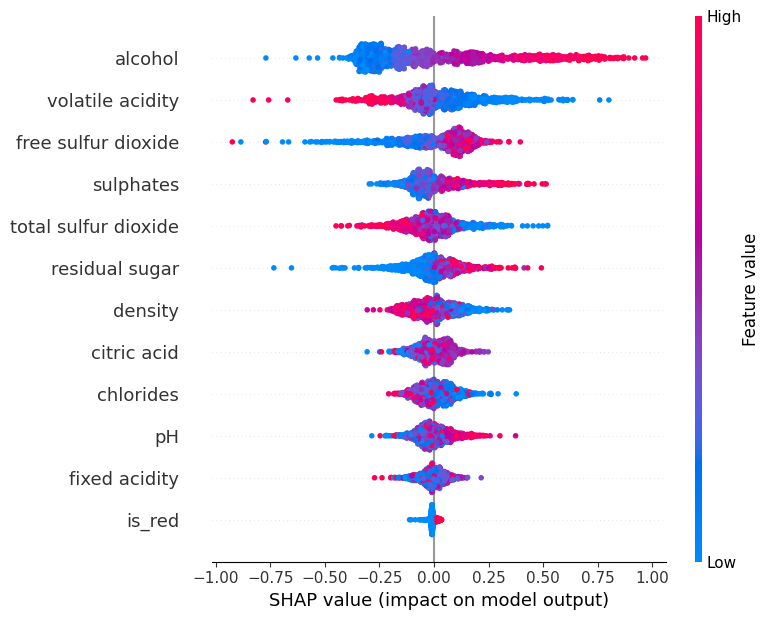

In [53]:
import shap


inf = xgb_dct['Полная выборка']
explainer = shap.TreeExplainer(inf['model'])
shap_values = explainer.shap_values(inf['X_test'])
feature_names = inf['X_train'].columns
shap.summary_plot(shap_values, inf['X_test'], feature_names=feature_names)

На этом графике показана интерпретация модели
🔎 Что показывает этот график?

Это глобальная интерпретация модели:

По оси X — SHAP value (вклад признака в предсказание)  
По оси Y — признаки, отсортированные по важности   

Каждая точка — один объект (бутылка вина)

Цвет точки — значение признака:

🔵 синий = низкое значение  
🔴 розовый/красный = высокое значение  

SHAP > 0 → признак увеличивает предсказанное качество  
SHAP < 0 → признак уменьшает предсказанное качество  
Чем дальше от 0 — тем сильнее влияние  



1️⃣ alcohol — самый важный признак

Красные точки справа → высокий алкоголь повышает качество  
Синие точки слева → низкий алкоголь понижает качество   
👉 Модель считает: чем выше алкоголь, тем выше quality.


2️⃣ volatile acidity

Красные точки слева → высокая летучая кислотность снижает качество   
Синие справа → низкая кислотность повышает качество  
👉 Высокая volatile acidity = хуже вкус → ниже quality.

3️⃣ free sulfur dioxide

Картина более смешанная, но:  
высокие значения чаще немного повышают качество, низкие — понижают  
Влияние умеренное.

4️⃣ sulphates

Высокие значения чаще справа → повышают качество  
Низкие → уменьшают

5️⃣ total sulfur dioxide

Влияние слабее, точки плотнее к 0   
Значит модель использует признак, но не очень сильно   

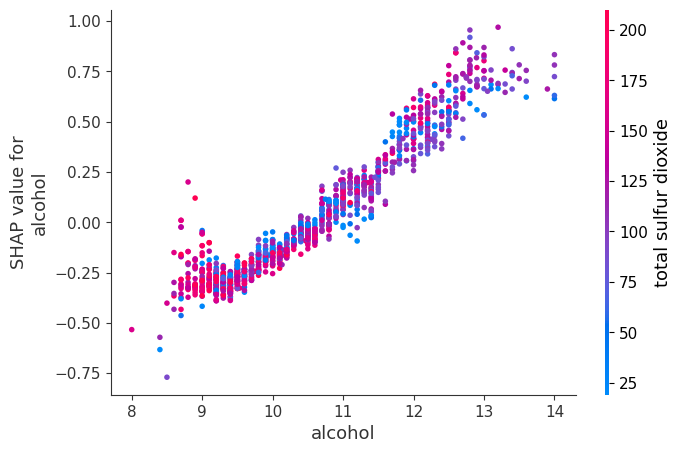

In [55]:
shap.dependence_plot('alcohol', shap_values, inf['X_test'], feature_names=feature_names)

Вау, это вообще что-то невероятно-красивое! О чёи он нам рассказывает?

1️⃣ Ось X — alcohol  
На горизонтальной оси отложено фактическое значение содержания алкоголя в вине.
Например, вино с алкоголем 9.0, 12.0, 13.5 и т.д.

2️⃣ Ось Y — SHAP value для alcohol
SHAP-значение показывает вклад конкретного признака в прогноз модели относительно базового значения (среднего прогноза).
Если SHAP > 0 → этот уровень алкоголя увеличивает прогнозируемое качество вина.

Ааа, он позволяет посмотреть взаимодействие между alcohol и total sulfur dioxide. Точки окрашены в зависимости от содержания total sulfur dioxide. 
Тренд увеличения качества с увеличением алкоголя уже не является сюрпризом, а влияние диоксида серы не очень явное. Но есть слабая отрицательная зависимость 

SHAP сам ищет наиболее коррелирующий с 'alcohol' признак по SHAP-значениям, и окрашивает точки этим признаком.

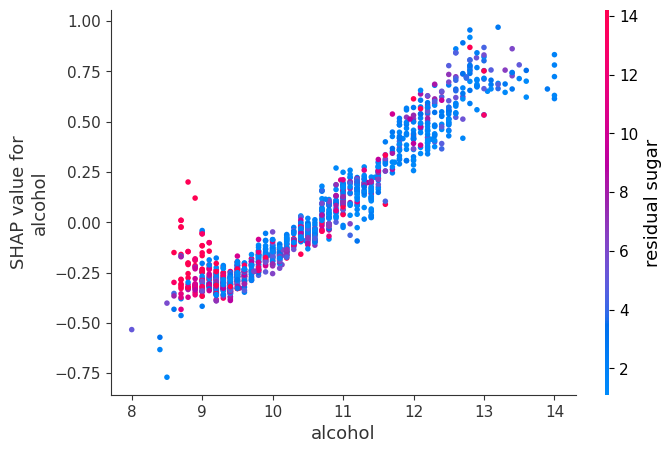

In [56]:
shap.dependence_plot('alcohol', shap_values, inf['X_test'], 
                     feature_names=feature_names, 
                     interaction_index='residual sugar')

А вот тут уже видно, что чем остаточного сахара меньше, тем лучше (если тупо)

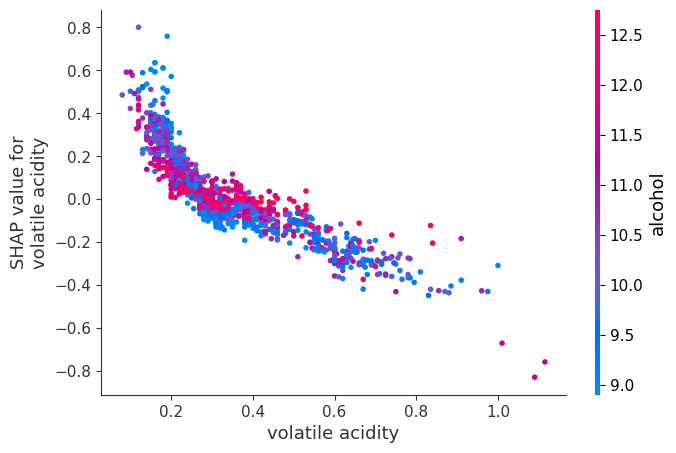

In [57]:
shap.dependence_plot('volatile acidity', shap_values, inf['X_test'], 
                     feature_names=feature_names)

In [ ]:
print("rf_full fitted:", hasattr(rf_full, "estimators_"))

rf_full fitted: False


---
### ВЫВОДЫ
---

Выводы делайте сами

## Функции, которые использовались в данной работе

In [ ]:
# Функция, проверяющая распределение на нормальность с помощью критерия согласия Пирсона или хи-квадрат ЭТА НЕ ИСПОЛЬЗОВАЛАСЬ
def chi2_norm_test(X, n_bins='auto', alpha=0.05):
    X = np.array(X)
    n = len(X)
    
    # Рассчитываем среднее и стандартное отклонение по выборке
    mean = np.mean(X)
    std = np.std(X, ddof=1)

    if n_bins == 'auto':
        # Определяем количество интервалов (Правило Стёрджеса)
        n_bins = int(np.ceil(1 + 3.322 * np.log10(n)))
        # Ограничиваем количество интервалов от 5 до 20
        n_bins = max(5, min(n_bins, 20))

    # Вычисляем наблюдаемые частоты и границы бинов (с помощью np.histogram - возвращает кортеж с частотами попадания в каждый бин и кортеж с границами бинов) 
    observed_freq, bin_edges = np.histogram(X, bins=n_bins) 


     # Вычисляем ожидаемые частоты для нормального распределения
    expected_freq = []

    # критерий хи2 требует равенства сумм частот двух сравниваемых распределений ∑Oi ​= ∑Ei = n. Нормальное распределений имеет бесконечные хвосты справа и слева,
    # поэтому первый бин нужно начинать с −∞, а последний заканчивать +∞
    for i in range(len(bin_edges) - 1):
        # У первого бина левая граница −∞, поэтому берём просто cdf на правой границе
        if i == 0:
            prob = stats.norm.cdf(bin_edges[1], mean, std)
        # У последнего бина правая граница +∞, поэтому 1 - cdf на левой границе
        elif i == len(bin_edges) - 2:
            prob = 1 - stats.norm.cdf(bin_edges[-2], mean, std)
        # У остальных бинов считаем ожидаемое значение как разность высот функции нормального распределения в конце и в начале интервала т. е. вероятность попадания в него
        else:
            prob = (stats.norm.cdf(bin_edges[i+1], mean, std) - stats.norm.cdf(bin_edges[i], mean, std))
        # Умножаем вероятности попадания в бин на n - вычисляем ожидаемые частоты
        expected_freq.append(prob * n)
    
    expected_freq = np.array(expected_freq)
    observed_freq = np.array(observed_freq)

    # Объединяем интервалы с маленькими ожидаемыми частотами чтобы все ожидаемые частоты были >= 5
    min_expected = 5
    observed_merged = []
    expected_merged = []
    
    temp_obs = 0
    temp_exp = 0
    
    for i in range(len(observed_freq)):
        temp_obs += observed_freq[i]
        temp_exp += expected_freq[i]
        
        # Если накопленная ожидаемая частота >= 5 - сохраняем в результат.
        # Тут проверяются именно ожидаемые частоты, потому, что тест хи2 использует формулу χ² = Σ [(Oᵢ - Eᵢ)² / Eᵢ] 
        # и если знаменатель будет слишком мал, может не получиться хи2 распределения статистики
        if temp_exp > min_expected and i != len(observed_freq) - 1:
            observed_merged.append(temp_obs)
            expected_merged.append(temp_exp)
            temp_obs = 0
            temp_exp = 0
        # Границы интервалов не меняем, т к они не используются в тесте

        # Последний проверим отдельно
        elif i == len(observed_freq) - 1:
            if temp_exp >= min_expected:
                # Если накопленная частота >= 5, сохраняем
                observed_merged.append(temp_obs)
                expected_merged.append(temp_exp)
            else:
                # Если < 5, объединяем с предыдущим интервалом
                # try-except для обработки случаев с очень маленькой выборкой, чтобы в следующей функции не возникало ошибок
                try:
                    observed_merged[-1] += temp_obs
                    expected_merged[-1] += temp_exp
                except IndexError:
                    # Список пустой - просто добавляем
                    observed_merged.append(temp_obs)
                    expected_merged.append(temp_exp)

    observed_merged = np.array(observed_merged)
    expected_merged = np.array(expected_merged)
    
    # Вычисляем статистику хи-квадрат
    chi2_stat, _ = stats.chisquare(observed_merged, expected_merged)
    
    # Степени свободы: k - 1 - p
    # k = количество интервалов
    # p = количество оцениваемых параметров (для нормального: 2 - mean и std)
    dof = len(observed_merged) - 1 - 2
    
    # Обрабатываем случай когда число степеней свободы <= 0
    if dof <= 0:
        return {
        'Статистика': np.nan,
        'P-value': np.nan,
        'Ошибка': 'Недостаточно степеней свободы'
    }

    # Считаем p-value со степенями свободы как P(χ2 >= χ2набл​) - правый "хвост" распределения
    p_value = stats.chi2.sf(chi2_stat, dof)
    
    return {
        'Статистика': round(chi2_stat, 2),
        'P-value': round(p_value, 5),
        'Степени свободы': dof,
        'Число интервалов': len(observed_merged),
        'Мин. ожидаемая частота': round(np.min(expected_merged), 5),
        'Нормальность': 'Да' if p_value > alpha else 'Нет'
    }


In [ ]:
# Функция, проверяющая распределение на нормальность пятью разными тестами
def norm_dist_check(X, alpha=0.05): 
    results = []
    n = len(X)
    # 1. Шапиро-Уилка
    # Работает для выборок от 3 до 5000 наблюдений. Наиболее эффективен для маленьких.
    if n > 5000:
        results.append({
            'Тест': 'Шапиро-Уилка',
            'Статистика': np.nan,
            'P-value': np.nan,
            'Критическое значение': np.nan,
            'Нормальность': 'Выборка > 5000'
        })
    else:
        stat, p = stats.shapiro(X)
        results.append({
            'Тест': 'Шапиро-Уилка',
            'Статистика': stat,
            'P-value': p,
            'Критическое значение': np.nan,
            'Нормальность': 'Да' if p > alpha else 'Нет'
        })
    
    # 2. Колмогорова-Смирнова с поправкой Лиллиефорса (для n >= 50)
    if n < 50:
        results.append({
            'Тест': 'Лиллиефорса',
            'Статистика': np.nan,
            'P-value': np.nan,
            'Критическое значение': np.nan,
            'Нормальность': 'Выборка < 50'
        })
    else:
        stat, p = lilliefors(X, 'norm')
        results.append({
            'Тест': 'Лиллиефорса',
            'Статистика': stat,
            'P-value': p,
            'Критическое значение': np.nan,
            'Нормальность': 'Да' if p > alpha else 'Нет'
        })
    
     # 3. Д'Агостино-Пирсона (normaltest) (n >= 20)
    if n < 20:
        results.append({
            'Тест': "Д'Агостино-Пирсона",
            'Статистика': np.nan,
            'P-value': np.nan,
            'Критическое значение': np.nan,
            'Нормальность': 'Выборка < 20'
        })
    else:
        stat, p = stats.normaltest(X, axis=0)
        results.append({
            'Тест': "Д'Агостино-Пирсона",
            'Статистика': stat,
            'P-value': p,
            'Критическое значение': np.nan,
            'Нормальность': 'Да' if p > alpha else 'Нет'
        })

    # 4. Хи-квадрат (Для больших выборок)
    if n < 100:
        results.append({
            'Тест': 'Хи-квадрат',
            'Статистика': np.nan,
            'P-value': np.nan,
            'Критическое значение': np.nan,
            'Нормальность': 'Выборка < 100'
        })
    else:
        chi2_result = chi2_norm_test(X, alpha=alpha)
        results.append({
        'Тест': 'Хи-квадрат',
        'Статистика': chi2_result['Статистика'],
        'P-value': chi2_result['P-value'],
        'Критическое значение': np.nan,
        'Нормальность': 'Да' if chi2_result['P-value'] > alpha else 'Нет'
            })

    # 5. Андерсона-Дарлинга  
    if n < 8:
        results.append({
            'Тест': 'Андерсона-Дарлинга',
            'Статистика': np.nan,
            'P-value': np.nan,
            'Критическое значение': np.nan,
            'Нормальность': 'Выборка < 8'
        })
    else:
        ad_result = stats.anderson(X, dist='norm')

        # В большинстве версий scipy функция stats.anderson() не возвращает p_value. Проверим, есть оно ими нет, чтобы избежать ошибок
        if hasattr(ad_result, 'pvalue') and ad_result.pvalue is not None: 
            ad_crit = ad_result.pvalue
            ad_normal = 'Да' if ad_p > alpha else 'Нет'
        else:
            # У этого теста в python уровни значимости только [0.15, 0.1, 0.05, 0.025, 0.01]
            # Если переданный в функцию alpha не соответствует ни одному из этих значений, используем для расчёта p_value ближайший более строгий уровень значимости
            levels = list(ad_result.significance_level / 100)
            if alpha in levels:
                crit_idx = levels.index(alpha)
            else:
                possible = levels[levels <= alpha]
                if len(possible) == 0:
                    crit_idx = len(levels) - 1  # самый строгий (1%)
                else:
                    crit_idx = levels.index(max(possible))

            # В данном тесте обычно не вычисляют p_value, вместо этого сравнивают заранее известное критическое значение со статистикой
            ad_crit = ad_result.critical_values[crit_idx]
            ad_normal = 'Да' if ad_result.statistic < ad_result.critical_values[crit_idx] else 'Нет'
        
        results.append({
            'Тест': 'Андерсона-Дарлинга',
            'Статистика': ad_result.statistic,
            'P-value': np.nan,
            'Критическое значение': ad_crit,
            'Нормальность': ad_normal
        })

    df_results = pd.DataFrame(results)
    
    # во время тестирования эти 3 строки нужно закомментировать
    print(f'\nРазмер выборки: n = {n}') 
    print(f'Уровень значимости: α = {alpha}')
    print('-' * 85)
    
    return df_results

In [ ]:
# Функция, чтобы рассчитать количество выбросов
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25) 
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1 # межквартильный размах = квантиль 0,75 - квантиль 0,25
    
    # нижняя граница
    lower_bound = Q1 - 1.5 * IQR
    # верхняя граница
    upper_bound = Q3 + 1.5 * IQR
    # коэффициент 1,5 чаще всего используется для определения границ выбросов
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    
    return round(len(outliers)/len(df)*100, 1)

In [ ]:
# функция для клонирования моделей
from sklearn.base import clone

def nonparametric_bootstrap(model, X, y, n=3000, random_state=42):
    '''
    Непараметрический bootstrap для оценки распределения коэффициентов.
    
    Параметры
    ----------
    model : модель sklearn
    X : pandas DataFrame
    y : pandas Series
    n : int - Количество bootstrap-итераций
    random_state : int or None
    
    Возвращает
    -------
    coef_df : pandas DataFrame таблица размера (количество итераций, количество признаков)
            Каждая строка — коэффициенты модели на одной bootstrap-выборке
    '''
    
    rng = np.random.default_rng(random_state) # генератор случайных чисел
    
    # берём из датафрейма массив чисел
    X_values = X.values 
    y_values = y.values 
    
    # находим размер данных
    n_samples = X_values.shape[0] # количество строк
    n_features = X_values.shape[1] # количество столбцов
    
    # ссоздаём матрицу для хранения bootstrap-оценок коэффициентов и заполняем его нулями
    coefs = np.zeros((n, n_features))
    
    for i in range(n):
        # генерируем случайные индексы от 0 до размера выборки - 1 с повторениями 
        idxs = rng.integers(0, n_samples, n_samples)
        
        X_boot = X_values[idxs]
        y_boot = y_values[idxs]
        
        # получаем "чистую" модель
        model_boot = clone(model)
        # обучаем её
        model_boot.fit(X_boot, y_boot)
        
        coefs[i] = model_boot.coef_
    
    feature_names = X.columns
    
    coef_df = pd.DataFrame(coefs, columns=feature_names)
    
    return coef_df

In [ ]:
def boot_table(coef_df):
    coef_median = coef_df.median()
    ci_lower = coef_df.quantile(0.025)
    ci_upper = coef_df.quantile(0.975)
    coef_std = coef_df.std()

    # Создаём таблицу
    coef_summary = pd.DataFrame({
        'медиана': coef_median,
        'стандартное отклонение': coef_std,
        'ДИ 2.5%': ci_lower,
        'ДИ 97.5%': ci_upper
    })

    # Сортируем от самых стабильных к менее стабильным (по стандартному отклонению)
    coef_summary_sorted = coef_summary.sort_values('стандартное отклонение')

    display(coef_summary_sorted)
    return None

In [ ]:
# функция построения тепловых карт с коэффициентами моделей
def plot_coefficients_heatmap(model, feature_names, title):
    # создаём Series коэффициентов
    coef = pd.Series(model.coef_, index=feature_names)
    
    # сортировка
    coef = coef.sort_values(ascending=False)
    
    # превращаем в DataFrame для heatmap (1 строка)
    coef_df = pd.DataFrame(coef).T
    coef_df.index = ['Коэффициенты']
    
    plt.figure(figsize=(10, 2))
    sns.heatmap(
        coef_df,
        annot=True,
        fmt='.3f',
        cmap='coolwarm',
        center=0,
        cbar=False
    )
    
    plt.title(title)
    plt.yticks(rotation=0)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()